# Immunity Score Genes & Time-Shifted Correlation Analysis
Check whether immunity/defense genes show improved correlation with microbiome genera when time-shifting the transcriptomic data (±1 timepoint).

In [1]:
import pandas as pd

pd.set_option("display.max_rows", 500)
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import Go_tools

In [13]:
# Load time-shifted correlation matrices (pre-computed from transcriptomic_time_shift notebook)
corr_dir = "/Users/michael/Data/Luke_terrace_experiment/General_data/Junk_data/Time_shifted_correlation/v2"

with open(f"{corr_dir}/corr_no_shift_remove_low_exp.p", "rb") as f:
    corr_no_shift = pickle.load(f)
with open(f"{corr_dir}/corr_forward_shift_remove_low_exp.p", "rb") as f:
    corr_forward = pickle.load(f)
with open(f"{corr_dir}/corr_backward_shift_remove_low_exp.p", "rb") as f:
    corr_backward = pickle.load(f)

print(f"No shift shape: {corr_no_shift.shape}")
print(f"Forward shift shape: {corr_forward.shape}")
print(f"Backward shift shape: {corr_backward.shape}")
print(f"Genera available: {list(corr_no_shift.columns[:10])}...")

No shift shape: (27418, 110)
Forward shift shape: (27418, 110)
Backward shift shape: (27418, 110)
Genera available: ['Abditibacterium', 'Actinocorallia', 'Actinomycetospora', 'Actinoplanes', 'Aeromicrobium', 'Aetherobacter', 'Agreia', 'Agrobacterium', 'Amnibacterium_382409', 'Amycolatopsis_D_380379']...


In [14]:
corr_backward

Genus,Abditibacterium,Actinocorallia,Actinomycetospora,Actinoplanes,Aeromicrobium,Aetherobacter,Agreia,Agrobacterium,Amnibacterium_382409,Amycolatopsis_D_380379,...,Roseomonas_507234,Rugamonas_570800,Solirubrobacter,Sphingomonas_L_486704,Sphingomonas_R_483406,Telluria_573210,Terracoccus,UBA1952,UBA5216,Variovorax
AT1G01010,0.400499,0.399450,0.157935,0.286456,0.278254,-0.056582,-0.226156,-0.155138,0.157094,-0.017337,...,-0.224440,-0.215060,-0.059712,0.164555,-0.051451,-0.004884,0.209657,-0.226960,0.236039,0.001221
AT1G01020,0.079293,0.453921,0.163128,0.111467,0.185191,-0.165320,-0.084696,-0.185983,0.395901,0.340581,...,-0.118268,-0.211395,0.450157,0.116013,-0.224817,-0.042125,0.330613,-0.181568,0.018157,-0.137363
AT1G03987,-0.055429,-0.055470,-0.163788,-0.239310,0.025674,0.104295,-0.092902,0.277096,-0.209001,-0.069195,...,-0.055429,0.201586,-0.255201,0.000000,-0.069195,-0.025179,-0.055429,-0.069338,-0.055470,-0.100716
AT1G01030,-0.051070,0.453921,-0.208951,-0.092228,0.133213,-0.304719,-0.280668,0.084593,0.473181,0.276268,...,0.025535,-0.121888,0.397561,0.136773,0.130304,0.064713,0.279543,-0.060523,0.145255,-0.214896
AT1G01040,-0.048382,0.435764,0.104781,-0.018934,0.184258,0.101152,0.063071,-0.073904,-0.025654,-0.124153,...,-0.157243,-0.222697,0.362910,0.354450,-0.210277,-0.052503,0.366900,-0.181568,-0.036314,0.153846
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ArthCt112,-0.060478,-0.199725,-0.041851,0.013743,-0.055091,0.585731,0.054962,-0.066880,-0.491868,-0.398183,...,-0.051070,-0.183901,0.064662,0.212792,0.114645,0.123932,0.159931,0.030261,-0.018157,0.241148
ArthCp088,-0.182778,0.000000,-0.021995,0.256528,-0.474339,0.192504,0.312654,0.001832,0.088365,-0.080531,...,0.133052,0.172598,-0.088484,-0.014044,0.165537,0.121490,0.151867,0.348006,-0.145255,0.035409
ArthCp083,-0.189498,-0.417607,0.058653,0.088563,-0.046376,0.712802,0.217146,-0.203084,-0.592269,-0.255576,...,-0.029567,-0.160684,-0.223067,0.107465,0.239917,-0.126984,-0.192186,0.000000,-0.344980,0.286935
ArthCp084,-0.164785,-0.164907,0.043203,0.262705,0.052902,0.127141,-0.276189,-0.114711,-0.205881,-0.205711,...,0.449889,0.125249,-0.017261,-0.079421,0.671916,0.016634,-0.164785,-0.206133,-0.164907,0.018615


In [17]:
# Load immunity score defense gene list (from immunity_score_and_circadian_rythm)
defense_gene_list = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Generated_data/load_correlated_defense_genes_union_GO_and_FLG.csv"
)
immunity_genes = defense_gene_list["gene"].tolist()
print(f"Immunity score genes: {len(immunity_genes)}")

# Load defense GO terms and GO matrix (from try_immunity_metrics_luke_non_self_recog)
arabi_go_matrix = pd.read_csv(
    "/Users/michael/Data/Reference_data/Arabdidopsis_go_matrix_from_tair_gaf.csv",
    index_col=0,
)
defense_terms = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Defense_go_terms.csv"
)

# Non-self recognition genes from Luke
non_self_recog_genes = [
    "AT1G02920",
    "AT1G02930",
    "AT1G21110",
    "AT1G21120",
    "AT1G26380",
    "AT1G26410",
    "AT1G26420",
    "AT1G35230",
    "AT1G64170",
    "AT1G65500",
    "AT1G76930",
    "AT2G19190",
    "AT2G25470",
    "AT2G30750",
    "AT2G39200",
    "AT2G43620",
    "AT3G46280",
    "AT4G12490",
    "AT4G12500",
    "AT4G23140",
    "AT4G23220",
    "AT4G28420",
    "AT5G24110",
    "AT5G64120",
]

# Add custom GO term for non-self recognition
defense_terms.loc[len(defense_terms)] = [
    "GO:Luke Custom",
    "General Non Self Recognition Genes",
    "Custom From Luke",
]
arabi_go_matrix["GO:Luke Custom"] = 0
arabi_go_matrix.loc[
    arabi_go_matrix.index.isin(non_self_recog_genes), "GO:Luke Custom"
] = 1

# Build GO term -> gene set mapping
go_terms = defense_terms["GO Term ID"].unique()
go_to_genes = {}
for go_term in go_terms:
    if go_term not in arabi_go_matrix.columns:
        continue
    genes = arabi_go_matrix[arabi_go_matrix[go_term] == 1].index.tolist()
    go_to_genes[go_term] = set(genes)

print(f"Defense GO terms loaded: {len(go_to_genes)}")
print(f"Non-self recognition genes: {len(non_self_recog_genes)}")
defense_terms

Immunity score genes: 199
Defense GO terms loaded: 25
Non-self recognition genes: 24


,GO Term ID,GO Term Description,Note
0,GO:0012501,programmed cell death,NaN
1,GO:0009626,Plant type hypersensitive response,NaN
2,GO:0042742,defense response to bacterium,NaN
3,GO:0071219,cellular response to molecule of bacterial origin,NaN
4,GO:0045087,innate immune response,NaN
5,GO:0009862,"systemic acquired resistance, salicylic acid m...",NaN
6,GO:0009861,jasmonic acid and ethylene-dependent systemic ...,NaN
7,GO:0034055,effector-mediated activation of host programme...,not enough genes
8,GO:0009682,induced systemic resistance,NaN
9,GO:0009626,plant-type hypersensitive response,NaN


## Part 1: Immunity Score Genes — Time-Shifted Correlation
For each immunity gene, compare its Spearman correlation with each genus across the three shifts (sync, forward = transcriptome leads, backward = microbiome leads). Identify which shift gives the best correlation.

In [18]:
def compare_shifts_for_gene_set(
    gene_list, corr_sync, corr_fwd, corr_bwd, label="gene_set"
):
    """
    For a set of genes, extract their correlations across shifts and summarize.
    Returns per-gene-genus comparison and per-gene average across genera.
    """
    # Find genes present in the correlation matrices
    genes_in_data = [g for g in gene_list if g in corr_sync.index]
    genes_missing = [g for g in gene_list if g not in corr_sync.index]

    if not genes_in_data:
        print(f"No genes from {label} found in correlation matrices.")
        return None, None

    print(
        f"{label}: {len(genes_in_data)}/{len(gene_list)} genes found in correlation data"
    )
    if genes_missing:
        print(
            f"  Missing: {genes_missing[:10]}{'...' if len(genes_missing) > 10 else ''}"
        )

    # Extract sub-matrices for this gene set
    sync_sub = corr_sync.loc[genes_in_data]
    fwd_sub = corr_fwd.loc[[g for g in genes_in_data if g in corr_fwd.index]]
    bwd_sub = corr_bwd.loc[[g for g in genes_in_data if g in corr_bwd.index]]

    # Per-gene-genus comparison
    rows = []
    for gene in genes_in_data:
        for genus in corr_sync.columns:
            r_sync = sync_sub.loc[gene, genus] if gene in sync_sub.index else np.nan
            r_fwd = fwd_sub.loc[gene, genus] if gene in fwd_sub.index else np.nan
            r_bwd = bwd_sub.loc[gene, genus] if gene in bwd_sub.index else np.nan

            corrs = {"sync": r_sync, "forward": r_fwd, "backward": r_bwd}
            valid = {k: v for k, v in corrs.items() if not np.isnan(v)}
            best_shift = max(valid, key=lambda k: abs(valid[k])) if valid else np.nan
            best_r = valid[best_shift] if valid else np.nan

            rows.append(
                {
                    "gene": gene,
                    "genus": genus,
                    "sync_r": r_sync,
                    "forward_r": r_fwd,
                    "backward_r": r_bwd,
                    "best_shift": best_shift,
                    "best_r": best_r,
                    "improvement_fwd": (
                        abs(r_fwd) - abs(r_sync)
                        if not (np.isnan(r_fwd) or np.isnan(r_sync))
                        else np.nan
                    ),
                    "improvement_bwd": (
                        abs(r_bwd) - abs(r_sync)
                        if not (np.isnan(r_bwd) or np.isnan(r_sync))
                        else np.nan
                    ),
                }
            )

    detail_df = pd.DataFrame(rows)

    # Per-gene summary: average |correlation| across all genera for each shift
    gene_summary = (
        detail_df.groupby("gene")
        .agg(
            mean_abs_sync=("sync_r", lambda x: x.abs().mean()),
            mean_abs_forward=("forward_r", lambda x: x.abs().mean()),
            mean_abs_backward=("backward_r", lambda x: x.abs().mean()),
            best_shift_mode=(
                "best_shift",
                lambda x: (
                    x.value_counts().index[0] if len(x.value_counts()) > 0 else np.nan
                ),
            ),
            n_genera=("genus", "count"),
        )
        .sort_values("mean_abs_sync", ascending=False)
    )

    gene_summary["best_avg_shift"] = (
        gene_summary[["mean_abs_sync", "mean_abs_forward", "mean_abs_backward"]]
        .idxmax(axis=1)
        .str.replace("mean_abs_", "")
    )

    return detail_df, gene_summary


# Run for immunity score genes
immunity_detail, immunity_summary = compare_shifts_for_gene_set(
    immunity_genes,
    corr_no_shift,
    corr_forward,
    corr_backward,
    label="Immunity Score Genes",
)
immunity_summary

Immunity Score Genes: 199/199 genes found in correlation data


,mean_abs_sync,mean_abs_forward,mean_abs_backward,best_shift_mode,n_genera,best_avg_shift
gene,,,,,,
AT5G05960,0.303501,0.274941,0.289540,sync,110,sync
AT3G47520,0.291938,0.274605,0.253129,sync,110,sync
AT4G33680,0.290208,0.260752,0.256741,sync,110,sync
AT2G17265,0.284634,0.260115,0.245637,sync,110,sync
AT5G24400,0.284043,0.280877,0.264129,forward,110,sync
AT3G01280,0.282132,0.260030,0.256688,sync,110,sync
AT2G14580,0.278925,0.274787,0.290634,backward,110,backward
AT1G80600,0.278680,0.246798,0.230890,sync,110,sync
AT1G55490,0.278615,0.253512,0.226614,sync,110,sync


In [19]:
immunity_detail

,gene,genus,sync_r,forward_r,backward_r,best_shift,best_r,improvement_fwd,improvement_bwd
0,AT1G01100,Abditibacterium,-0.008578,0.122300,-0.024191,forward,0.122300,0.113722,0.015613
1,AT1G01100,Actinocorallia,0.240346,0.272352,0.363137,backward,0.363137,0.032007,0.122791
2,AT1G01100,Actinomycetospora,0.135835,0.109652,0.493050,backward,0.493050,-0.026183,0.357216
3,AT1G01100,Actinoplanes,-0.098015,0.120916,-0.178959,backward,-0.178959,0.022901,0.080944
4,AT1G01100,Aeromicrobium,0.440024,0.206905,0.468114,backward,0.468114,-0.233119,0.028090
...,...,...,...,...,...,...,...,...,...
21885,AT5G67500,Telluria_573210,0.335523,0.038462,0.063492,sync,0.335523,-0.297061,-0.272031
21886,AT5G67500,Terracoccus,0.096808,0.040319,0.100797,backward,0.100797,-0.056489,0.003989
21887,AT5G67500,UBA1952,-0.035737,0.136176,-0.015131,forward,0.136176,0.100439,-0.020606
21888,AT5G67500,UBA5216,0.309016,0.326823,0.127098,forward,0.326823,0.017807,-0.181918


In [20]:
# Overall shift distribution for immunity genes
shift_counts = immunity_detail["best_shift"].value_counts()
print("Best shift distribution for immunity gene-genus pairs:")
print(shift_counts)
print(f"\nOverall mean |correlation| across all immunity gene-genus pairs:")
print(f"  Sync:     {immunity_detail['sync_r'].abs().mean():.4f}")
print(f"  Forward:  {immunity_detail['forward_r'].abs().mean():.4f}")
print(f"  Backward: {immunity_detail['backward_r'].abs().mean():.4f}")

# Distribution of which shift is best per gene (averaged across genera)
print(f"\nPer-gene best average shift:")
print(immunity_summary["best_avg_shift"].value_counts())

Best shift distribution for immunity gene-genus pairs:
best_shift
sync        7912
forward     7253
backward    6725
Name: count, dtype: int64

Overall mean |correlation| across all immunity gene-genus pairs:
  Sync:     0.2319
  Forward:  0.2202
  Backward: 0.2091

Per-gene best average shift:
best_avg_shift
sync        142
forward      38
backward     19
Name: count, dtype: int64


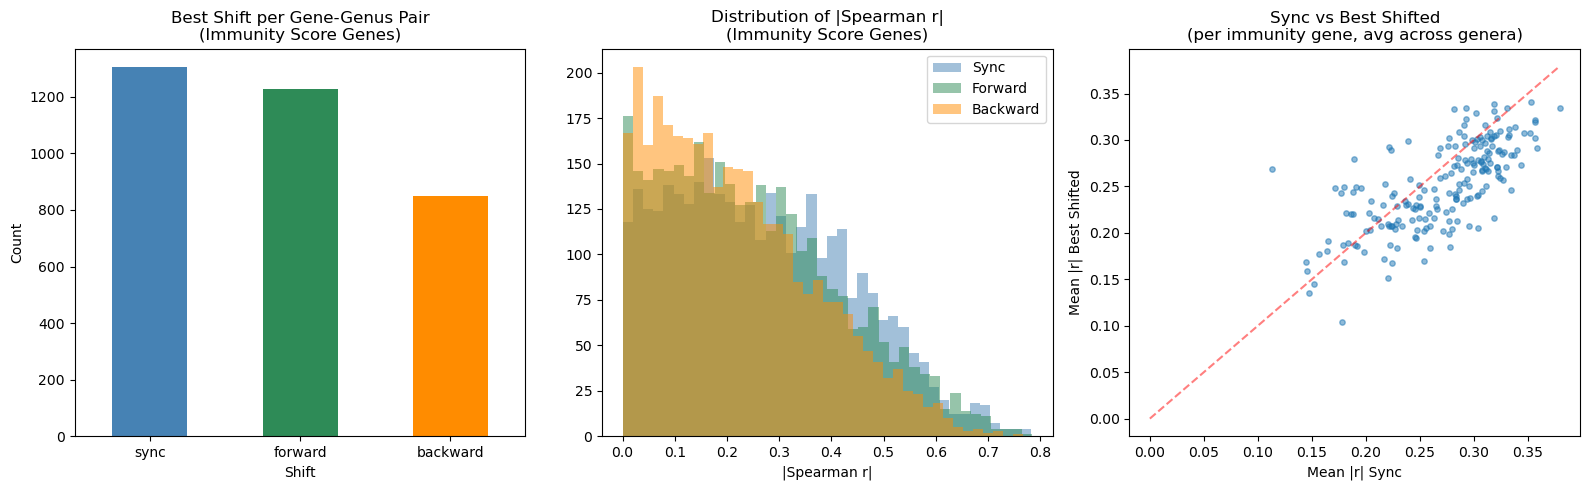

In [13]:
# Plot: per-gene mean |correlation| across shifts (immunity genes)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Bar chart of best shift counts
shift_counts.plot(kind="bar", ax=axes[0], color=["steelblue", "seagreen", "darkorange"])
axes[0].set_title("Best Shift per Gene-Genus Pair\n(Immunity Score Genes)")
axes[0].set_ylabel("Count")
axes[0].set_xlabel("Shift")
axes[0].tick_params(axis="x", rotation=0)

# 2. Histogram overlay of |correlations| for each shift
for col, label, color in [
    ("sync_r", "Sync", "steelblue"),
    ("forward_r", "Forward", "seagreen"),
    ("backward_r", "Backward", "darkorange"),
]:
    axes[1].hist(
        immunity_detail[col].abs().dropna(),
        bins=40,
        alpha=0.5,
        label=label,
        color=color,
    )
axes[1].set_title("Distribution of |Spearman r|\n(Immunity Score Genes)")
axes[1].set_xlabel("|Spearman r|")
axes[1].legend()

# 3. Scatter: sync vs best shifted per gene (avg across genera)
axes[2].scatter(
    immunity_summary["mean_abs_sync"],
    immunity_summary[["mean_abs_forward", "mean_abs_backward"]].max(axis=1),
    alpha=0.5,
    s=15,
)
max_val = max(
    immunity_summary["mean_abs_sync"].max(),
    immunity_summary[["mean_abs_forward", "mean_abs_backward"]].max().max(),
)
axes[2].plot([0, max_val], [0, max_val], "r--", alpha=0.5)
axes[2].set_xlabel("Mean |r| Sync")
axes[2].set_ylabel("Mean |r| Best Shifted")
axes[2].set_title("Sync vs Best Shifted\n(per immunity gene, avg across genera)")

plt.tight_layout()
plt.show()

In [21]:
# Top immunity genes where shifted correlation is notably better than sync
# Focus on specific genera of interest (Pseudomonas, Sphingomonas, etc.)
pseudomonas_genera = [g for g in corr_no_shift.columns if "Pseudomonas" in g]
print(f"Pseudomonas genera in data: {pseudomonas_genera}")

# Top gene-genus pairs where forward shift (transcriptome leads) improves most
top_fwd_immunity = immunity_detail.nlargest(20, "improvement_fwd")[
    ["gene", "genus", "sync_r", "forward_r", "improvement_fwd"]
]
print(
    "\nTop 20 immunity gene-genus pairs where transcriptome LEADS (forward shift better):"
)
display(top_fwd_immunity)

# Top gene-genus pairs where backward shift (microbiome leads) improves most
top_bwd_immunity = immunity_detail.nlargest(20, "improvement_bwd")[
    ["gene", "genus", "sync_r", "backward_r", "improvement_bwd"]
]
print(
    "\nTop 20 immunity gene-genus pairs where microbiome LEADS (backward shift better):"
)
display(top_bwd_immunity)

Pseudomonas genera in data: ['Pseudomonas_B_650453', 'Pseudomonas_E_647464', 'Pseudomonas_E_647626', 'Pseudomonas_M']

Top 20 immunity gene-genus pairs where transcriptome LEADS (forward shift better):


,gene,genus,sync_r,forward_r,improvement_fwd
19808,AT5G52810,Amnibacterium_382409,0.030308,0.592585,0.562277
10197,AT3G23400,Patulibacter,0.002401,-0.561190,0.558789
20769,AT5G59730,Pseudomonas_E_647464,-0.136289,-0.692918,0.556629
3241,AT1G62300,Klenkia,-0.180624,-0.697192,0.516568
21348,AT5G64810,Amnibacterium_382409,0.120099,0.634709,0.514610
520,AT1G08450,Pelomonas,0.108568,0.614012,0.505443
559,AT1G08830,Amycolatopsis_D_380379,0.000000,0.502762,0.502762
6278,AT2G27050,Amnibacterium_382409,0.205075,0.699954,0.494878
3488,AT1G65690,Paucimonas,0.000831,-0.493625,0.492795
2738,AT1G42540,Rhodoferax_C,-0.084291,-0.573260,0.488969



Top 20 immunity gene-genus pairs where microbiome LEADS (backward shift better):


,gene,genus,sync_r,backward_r,improvement_bwd
4734,AT2G02860,Aeromicrobium,0.060258,0.629028,0.568770
20741,AT5G59730,Methylotenera_A_557637,0.005720,-0.565416,0.559696
2065,AT1G29340,Pseudoduganella_570666,-0.002739,0.537204,0.534465
17074,AT5G09978,Caulobacter_487784,-0.058428,0.592551,0.534123
670,AT1G09560,Aquabacterium_A_592457,0.035004,0.561304,0.526300
11178,AT3G49120,Naasia_381491,-0.019882,-0.525961,0.506079
21187,AT5G61210,Mycobacterium,0.008005,-0.513067,0.505062
10188,AT3G23400,Naasia_381491,0.007647,-0.485675,0.478028
7887,AT2G42010,Patulibacter,-0.162075,-0.639604,0.477529
7670,AT2G40750,Pelomonas,0.039915,0.516867,0.476952


## Part 2: Defense GO Terms & Non-Self Recognition Genes — Time-Shifted Correlation
For each defense GO term and the non-self recognition gene set, compare mean |Spearman r| across sync, forward, and backward shifts.

In [19]:
# Analyze each defense GO term
go_term_shift_results = []

for go_term, genes in go_to_genes.items():
    gene_list = list(genes)
    term_desc = defense_terms.loc[
        defense_terms["GO Term ID"] == go_term, "GO Term Description"
    ].values
    term_label = term_desc[0] if len(term_desc) > 0 else go_term

    detail_df, summary_df = compare_shifts_for_gene_set(
        gene_list,
        corr_no_shift,
        corr_forward,
        corr_backward,
        label=f"{go_term} ({term_label})",
    )

    if detail_df is None:
        continue

    genes_in_data = len(summary_df)
    mean_sync = detail_df["sync_r"].abs().mean()
    mean_fwd = detail_df["forward_r"].abs().mean()
    mean_bwd = detail_df["backward_r"].abs().mean()

    # Count best shifts
    shift_counts_go = detail_df["best_shift"].value_counts()

    go_term_shift_results.append(
        {
            "go_term_id": go_term,
            "go_term_name": term_label,
            "n_genes_in_data": genes_in_data,
            "mean_abs_sync": mean_sync,
            "mean_abs_forward": mean_fwd,
            "mean_abs_backward": mean_bwd,
            "best_overall": ["sync", "forward", "backward"][
                np.argmax([mean_sync, mean_fwd, mean_bwd])
            ],
            "pct_sync_best": shift_counts_go.get("sync", 0) / len(detail_df) * 100,
            "pct_forward_best": shift_counts_go.get("forward", 0)
            / len(detail_df)
            * 100,
            "pct_backward_best": shift_counts_go.get("backward", 0)
            / len(detail_df)
            * 100,
        }
    )

go_shift_df = pd.DataFrame(go_term_shift_results)
go_shift_df = go_shift_df.sort_values("mean_abs_sync", ascending=False)
print(f"\n{'='*80}")
print("Summary: Time-shifted correlation for each defense GO term")
print(f"{'='*80}")
go_shift_df

GO:0012501 (programmed cell death): 34/34 genes found in correlation data
GO:0009626 (Plant type hypersensitive response): 54/54 genes found in correlation data


IndexError: index 0 is out of bounds for axis 0 with size 0

NameError: name 'go_shift_df' is not defined

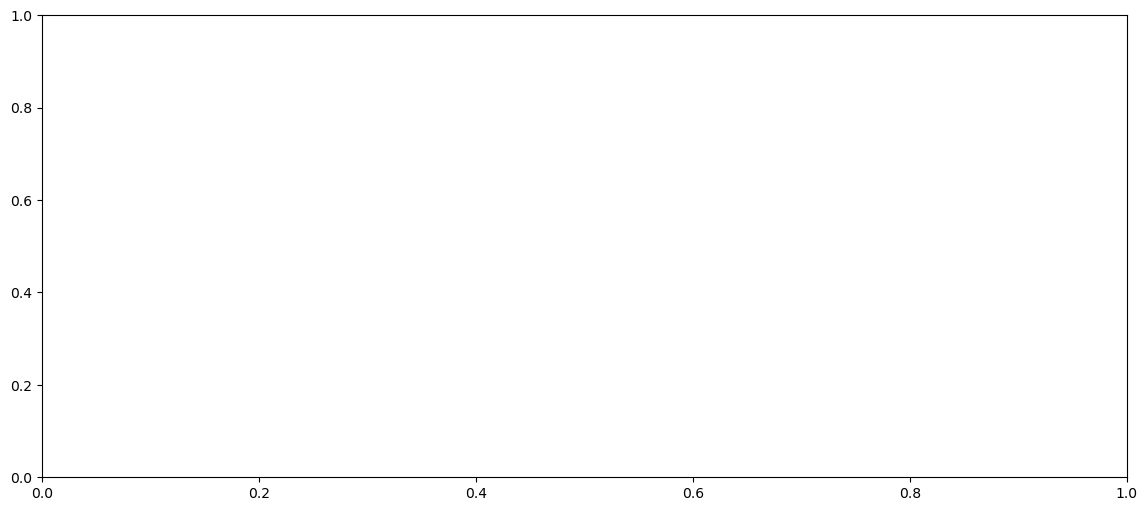

In [ ]:
# Grouped bar chart: mean |r| per GO term across shifts
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(go_shift_df))
width = 0.25

ax.bar(x - width, go_shift_df["mean_abs_sync"], width, label="Sync", color="steelblue")
ax.bar(
    x,
    go_shift_df["mean_abs_forward"],
    width,
    label="Forward (trans leads)",
    color="seagreen",
)
ax.bar(
    x + width,
    go_shift_df["mean_abs_backward"],
    width,
    label="Backward (micro leads)",
    color="darkorange",
)

ax.set_xticks(x)
ax.set_xticklabels(go_shift_df["go_term_name"], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Mean |Spearman r|")
ax.set_title("Mean |Correlation| per Defense GO Term Across Time Shifts")
ax.legend()
plt.tight_layout()
plt.show()

In [18]:
# Detailed look: Non-self recognition genes specifically
nonself_detail, nonself_summary = compare_shifts_for_gene_set(
    non_self_recog_genes,
    corr_no_shift,
    corr_forward,
    corr_backward,
    label="Non-Self Recognition Genes (Luke)",
)

print("\nPer-gene summary (non-self recognition):")
display(nonself_summary)

print(f"\nOverall mean |correlation| for non-self recognition genes:")
print(f"  Sync:     {nonself_detail['sync_r'].abs().mean():.4f}")
print(f"  Forward:  {nonself_detail['forward_r'].abs().mean():.4f}")
print(f"  Backward: {nonself_detail['backward_r'].abs().mean():.4f}")

# Best shift distribution
print(f"\nBest shift distribution (non-self recognition):")
print(nonself_detail["best_shift"].value_counts())

Non-Self Recognition Genes (Luke): 24/24 genes found in correlation data

Per-gene summary (non-self recognition):


,mean_abs_sync,mean_abs_forward,mean_abs_backward,best_shift_mode,n_genera,best_avg_shift
gene,,,,,,
AT4G12490,0.291260,0.216400,0.299749,backward,137,backward
AT1G35230,0.258793,0.185382,0.178874,sync,137,sync
AT1G65500,0.252156,0.192095,0.150844,sync,137,sync
AT4G12500,0.227338,0.217842,0.298152,backward,137,backward
AT2G30750,0.223956,0.172583,0.162436,backward,137,sync
AT1G02930,0.219833,0.186754,0.193314,backward,137,sync
AT2G19190,0.205687,0.215668,0.159997,forward,137,forward
AT4G23140,0.198032,0.269626,0.254586,backward,137,forward
AT2G43620,0.190957,0.223225,0.253603,backward,137,backward



Overall mean |correlation| for non-self recognition genes:
  Sync:     0.1794
  Forward:  0.1793
  Backward: 0.1924

Best shift distribution (non-self recognition):
best_shift
backward    169
sync        120
forward     119
Name: count, dtype: int64


In [ ]:
# Top non-self recognition gene-genus pairs with biggest improvements from shifting
top_fwd_nonself = nonself_detail.nlargest(15, "improvement_fwd")[
    ["gene", "genus", "sync_r", "forward_r", "improvement_fwd"]
]
print("Top 15 non-self recognition gene-genus pairs where transcriptome LEADS:")
display(top_fwd_nonself)

top_bwd_nonself = nonself_detail.nlargest(15, "improvement_bwd")[
    ["gene", "genus", "sync_r", "backward_r", "improvement_bwd"]
]
print("\nTop 15 non-self recognition gene-genus pairs where microbiome LEADS:")
display(top_bwd_nonself)

## Summary Comparison
Compare all gene sets side-by-side: immunity score genes, each defense GO term, and non-self recognition genes.

In [ ]:
# Build a unified summary: one row per gene set
summary_rows = []

# Immunity score genes
summary_rows.append(
    {
        "gene_set": "Immunity Score Genes",
        "n_genes": len([g for g in immunity_genes if g in corr_no_shift.index]),
        "mean_abs_sync": immunity_detail["sync_r"].abs().mean(),
        "mean_abs_forward": immunity_detail["forward_r"].abs().mean(),
        "mean_abs_backward": immunity_detail["backward_r"].abs().mean(),
    }
)

# Each GO term
for _, row in go_shift_df.iterrows():
    summary_rows.append(
        {
            "gene_set": f"{row['go_term_id']} ({row['go_term_name']})",
            "n_genes": row["n_genes_in_data"],
            "mean_abs_sync": row["mean_abs_sync"],
            "mean_abs_forward": row["mean_abs_forward"],
            "mean_abs_backward": row["mean_abs_backward"],
        }
    )

# Non-self recognition genes
summary_rows.append(
    {
        "gene_set": "Non-Self Recognition (Luke)",
        "n_genes": len([g for g in non_self_recog_genes if g in corr_no_shift.index]),
        "mean_abs_sync": nonself_detail["sync_r"].abs().mean(),
        "mean_abs_forward": nonself_detail["forward_r"].abs().mean(),
        "mean_abs_backward": nonself_detail["backward_r"].abs().mean(),
    }
)

full_summary = pd.DataFrame(summary_rows)
full_summary["best_shift"] = (
    full_summary[["mean_abs_sync", "mean_abs_forward", "mean_abs_backward"]]
    .idxmax(axis=1)
    .str.replace("mean_abs_", "")
)
full_summary["fwd_vs_sync_diff"] = (
    full_summary["mean_abs_forward"] - full_summary["mean_abs_sync"]
)
full_summary["bwd_vs_sync_diff"] = (
    full_summary["mean_abs_backward"] - full_summary["mean_abs_sync"]
)

print(
    "Full summary — mean |Spearman r| across all genera, per gene set and time shift:"
)
full_summary

In [ ]:
# Heatmap: gene sets × shifts
heatmap_data = full_summary.set_index("gene_set")[
    ["mean_abs_sync", "mean_abs_forward", "mean_abs_backward"]
]
heatmap_data.columns = ["Sync", "Forward\n(Trans leads)", "Backward\n(Micro leads)"]

fig, ax = plt.subplots(figsize=(8, max(6, len(heatmap_data) * 0.4)))
sns.heatmap(
    heatmap_data.astype(float),
    annot=True,
    fmt=".4f",
    cmap="YlOrRd",
    ax=ax,
    linewidths=0.5,
    linecolor="white",
)
ax.set_title("Mean |Spearman r| per Gene Set and Time Shift")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

---
# Circadian Experiment 1 — Time-Shifted Correlation Analysis
Same analysis as above but using the circadian experiment 1 time-shifted correlations.

In [ ]:
# Load circadian experiment 1 time-shifted correlation matrices
circ_dir = "/Users/michael/Data/Luke_terrace_experiment/General_data/Junk_data/Time_shifted_correlation/Circadian_1"

with open(f"{circ_dir}/corr_no_shift.p", "rb") as f:
    circ_corr_no_shift = pickle.load(f)
with open(f"{circ_dir}/corr_forward_shift.p", "rb") as f:
    circ_corr_forward = pickle.load(f)
with open(f"{circ_dir}/corr_backward_shift.p", "rb") as f:
    circ_corr_backward = pickle.load(f)

print(f"Circadian 1 — No shift shape: {circ_corr_no_shift.shape}")
print(f"Circadian 1 — Forward shift shape: {circ_corr_forward.shape}")
print(f"Circadian 1 — Backward shift shape: {circ_corr_backward.shape}")
print(f"Genera available: {list(circ_corr_no_shift.columns[:10])}...")

### Circadian 1: Immunity Score Genes

In [ ]:
# Immunity score genes — circadian 1
circ_imm_detail, circ_imm_summary = compare_shifts_for_gene_set(
    immunity_genes,
    circ_corr_no_shift,
    circ_corr_forward,
    circ_corr_backward,
    label="Circadian 1 — Immunity Score Genes",
)

print(f"\nOverall mean |correlation| (Circadian 1, immunity genes):")
print(f"  Sync:     {circ_imm_detail['sync_r'].abs().mean():.4f}")
print(f"  Forward:  {circ_imm_detail['forward_r'].abs().mean():.4f}")
print(f"  Backward: {circ_imm_detail['backward_r'].abs().mean():.4f}")

print(f"\nBest shift distribution:")
print(circ_imm_detail["best_shift"].value_counts())

print(f"\nPer-gene best average shift:")
print(circ_imm_summary["best_avg_shift"].value_counts())

In [ ]:
# Plots for circadian 1 immunity genes
circ_shift_counts = circ_imm_detail["best_shift"].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

circ_shift_counts.plot(
    kind="bar", ax=axes[0], color=["steelblue", "seagreen", "darkorange"]
)
axes[0].set_title("Best Shift per Gene-Genus Pair\n(Circadian 1 — Immunity Genes)")
axes[0].set_ylabel("Count")
axes[0].set_xlabel("Shift")
axes[0].tick_params(axis="x", rotation=0)

for col, label, color in [
    ("sync_r", "Sync", "steelblue"),
    ("forward_r", "Forward", "seagreen"),
    ("backward_r", "Backward", "darkorange"),
]:
    axes[1].hist(
        circ_imm_detail[col].abs().dropna(),
        bins=40,
        alpha=0.5,
        label=label,
        color=color,
    )
axes[1].set_title("Distribution of |Spearman r|\n(Circadian 1 — Immunity Genes)")
axes[1].set_xlabel("|Spearman r|")
axes[1].legend()

axes[2].scatter(
    circ_imm_summary["mean_abs_sync"],
    circ_imm_summary[["mean_abs_forward", "mean_abs_backward"]].max(axis=1),
    alpha=0.5,
    s=15,
)
max_val = max(
    circ_imm_summary["mean_abs_sync"].max(),
    circ_imm_summary[["mean_abs_forward", "mean_abs_backward"]].max().max(),
)
axes[2].plot([0, max_val], [0, max_val], "r--", alpha=0.5)
axes[2].set_xlabel("Mean |r| Sync")
axes[2].set_ylabel("Mean |r| Best Shifted")
axes[2].set_title("Sync vs Best Shifted\n(Circadian 1, per immunity gene)")

plt.tight_layout()
plt.show()

In [ ]:
# Top immunity gene-genus pairs with biggest shift improvements (Circadian 1)
top_fwd_circ_imm = circ_imm_detail.nlargest(20, "improvement_fwd")[
    ["gene", "genus", "sync_r", "forward_r", "improvement_fwd"]
]
print("Circadian 1 — Top 20 immunity gene-genus pairs where transcriptome LEADS:")
display(top_fwd_circ_imm)

top_bwd_circ_imm = circ_imm_detail.nlargest(20, "improvement_bwd")[
    ["gene", "genus", "sync_r", "backward_r", "improvement_bwd"]
]
print("\nCircadian 1 — Top 20 immunity gene-genus pairs where microbiome LEADS:")
display(top_bwd_circ_imm)

### Circadian 1: Defense GO Terms & Non-Self Recognition Genes

In [ ]:
# Analyze each defense GO term — Circadian 1
circ_go_term_shift_results = []

for go_term, genes in go_to_genes.items():
    gene_list = list(genes)
    term_desc = defense_terms.loc[
        defense_terms["GO Term ID"] == go_term, "GO Term Description"
    ].values
    term_label = term_desc[0] if len(term_desc) > 0 else go_term

    detail_df, summary_df = compare_shifts_for_gene_set(
        gene_list,
        circ_corr_no_shift,
        circ_corr_forward,
        circ_corr_backward,
        label=f"Circ1 — {go_term} ({term_label})",
    )

    if detail_df is None:
        continue

    genes_in_data = len(summary_df)
    mean_sync = detail_df["sync_r"].abs().mean()
    mean_fwd = detail_df["forward_r"].abs().mean()
    mean_bwd = detail_df["backward_r"].abs().mean()

    shift_counts_go = detail_df["best_shift"].value_counts()

    circ_go_term_shift_results.append(
        {
            "go_term_id": go_term,
            "go_term_name": term_label,
            "n_genes_in_data": genes_in_data,
            "mean_abs_sync": mean_sync,
            "mean_abs_forward": mean_fwd,
            "mean_abs_backward": mean_bwd,
            "best_overall": ["sync", "forward", "backward"][
                np.argmax([mean_sync, mean_fwd, mean_bwd])
            ],
            "pct_sync_best": shift_counts_go.get("sync", 0) / len(detail_df) * 100,
            "pct_forward_best": shift_counts_go.get("forward", 0)
            / len(detail_df)
            * 100,
            "pct_backward_best": shift_counts_go.get("backward", 0)
            / len(detail_df)
            * 100,
        }
    )

circ_go_shift_df = pd.DataFrame(circ_go_term_shift_results)
circ_go_shift_df = circ_go_shift_df.sort_values("mean_abs_sync", ascending=False)
print(f"\n{'='*80}")
print("Circadian 1 — Time-shifted correlation for each defense GO term")
print(f"{'='*80}")
circ_go_shift_df

In [ ]:
# Grouped bar chart: mean |r| per GO term across shifts — Circadian 1
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(circ_go_shift_df))
width = 0.25

ax.bar(
    x - width, circ_go_shift_df["mean_abs_sync"], width, label="Sync", color="steelblue"
)
ax.bar(
    x,
    circ_go_shift_df["mean_abs_forward"],
    width,
    label="Forward (trans leads)",
    color="seagreen",
)
ax.bar(
    x + width,
    circ_go_shift_df["mean_abs_backward"],
    width,
    label="Backward (micro leads)",
    color="darkorange",
)

ax.set_xticks(x)
ax.set_xticklabels(
    circ_go_shift_df["go_term_name"], rotation=45, ha="right", fontsize=8
)
ax.set_ylabel("Mean |Spearman r|")
ax.set_title("Circadian 1 — Mean |Correlation| per Defense GO Term Across Time Shifts")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Non-self recognition genes — Circadian 1
circ_nonself_detail, circ_nonself_summary = compare_shifts_for_gene_set(
    non_self_recog_genes,
    circ_corr_no_shift,
    circ_corr_forward,
    circ_corr_backward,
    label="Circadian 1 — Non-Self Recognition Genes (Luke)",
)

print("\nPer-gene summary (Circadian 1, non-self recognition):")
display(circ_nonself_summary)

print(f"\nOverall mean |correlation| (Circadian 1, non-self recognition):")
print(f"  Sync:     {circ_nonself_detail['sync_r'].abs().mean():.4f}")
print(f"  Forward:  {circ_nonself_detail['forward_r'].abs().mean():.4f}")
print(f"  Backward: {circ_nonself_detail['backward_r'].abs().mean():.4f}")

print(f"\nBest shift distribution:")
print(circ_nonself_detail["best_shift"].value_counts())

In [ ]:
# Top non-self recognition gene-genus pairs — Circadian 1
top_fwd_circ_ns = circ_nonself_detail.nlargest(15, "improvement_fwd")[
    ["gene", "genus", "sync_r", "forward_r", "improvement_fwd"]
]
print("Circadian 1 — Top 15 non-self recognition pairs where transcriptome LEADS:")
display(top_fwd_circ_ns)

top_bwd_circ_ns = circ_nonself_detail.nlargest(15, "improvement_bwd")[
    ["gene", "genus", "sync_r", "backward_r", "improvement_bwd"]
]
print("\nCircadian 1 — Top 15 non-self recognition pairs where microbiome LEADS:")
display(top_bwd_circ_ns)

### Circadian 1: Summary Comparison

In [ ]:
# Unified summary for Circadian 1
circ_summary_rows = []

# Immunity score genes
circ_summary_rows.append(
    {
        "gene_set": "Immunity Score Genes",
        "n_genes": len([g for g in immunity_genes if g in circ_corr_no_shift.index]),
        "mean_abs_sync": circ_imm_detail["sync_r"].abs().mean(),
        "mean_abs_forward": circ_imm_detail["forward_r"].abs().mean(),
        "mean_abs_backward": circ_imm_detail["backward_r"].abs().mean(),
    }
)

# Each GO term
for _, row in circ_go_shift_df.iterrows():
    circ_summary_rows.append(
        {
            "gene_set": f"{row['go_term_id']} ({row['go_term_name']})",
            "n_genes": row["n_genes_in_data"],
            "mean_abs_sync": row["mean_abs_sync"],
            "mean_abs_forward": row["mean_abs_forward"],
            "mean_abs_backward": row["mean_abs_backward"],
        }
    )

# Non-self recognition genes
circ_summary_rows.append(
    {
        "gene_set": "Non-Self Recognition (Luke)",
        "n_genes": len(
            [g for g in non_self_recog_genes if g in circ_corr_no_shift.index]
        ),
        "mean_abs_sync": circ_nonself_detail["sync_r"].abs().mean(),
        "mean_abs_forward": circ_nonself_detail["forward_r"].abs().mean(),
        "mean_abs_backward": circ_nonself_detail["backward_r"].abs().mean(),
    }
)

circ_full_summary = pd.DataFrame(circ_summary_rows)
circ_full_summary["best_shift"] = (
    circ_full_summary[["mean_abs_sync", "mean_abs_forward", "mean_abs_backward"]]
    .idxmax(axis=1)
    .str.replace("mean_abs_", "")
)
circ_full_summary["fwd_vs_sync_diff"] = (
    circ_full_summary["mean_abs_forward"] - circ_full_summary["mean_abs_sync"]
)
circ_full_summary["bwd_vs_sync_diff"] = (
    circ_full_summary["mean_abs_backward"] - circ_full_summary["mean_abs_sync"]
)

print("Circadian 1 — Full summary (mean |Spearman r| across all genera, per gene set):")
circ_full_summary

In [ ]:
# Heatmap: Circadian 1 gene sets × shifts
circ_heatmap_data = circ_full_summary.set_index("gene_set")[
    ["mean_abs_sync", "mean_abs_forward", "mean_abs_backward"]
]
circ_heatmap_data.columns = [
    "Sync",
    "Forward\n(Trans leads)",
    "Backward\n(Micro leads)",
]

fig, ax = plt.subplots(figsize=(8, max(6, len(circ_heatmap_data) * 0.4)))
sns.heatmap(
    circ_heatmap_data.astype(float),
    annot=True,
    fmt=".4f",
    cmap="YlOrRd",
    ax=ax,
    linewidths=0.5,
    linecolor="white",
)
ax.set_title("Circadian 1 — Mean |Spearman r| per Gene Set and Time Shift")
ax.set_ylabel("")
plt.tight_layout()
plt.show()